In [160]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mdmahfuzsumon/global-gold-price-dataset-18332026-monthly/monthly.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

****LOAD DATASET:-****

In [139]:
df=pd.read_csv('/kaggle/input/datasets/mdmahfuzsumon/global-gold-price-dataset-18332026-monthly/monthly.csv')

**UNDERSTANDING DATASET**

In [140]:
df.columns

Index(['Date', 'Price'], dtype='object')

In [141]:
df.shape

(2318, 2)

In [142]:
print(df.head(3))

      Date  Price
0  1833-01  18.93
1  1833-02  18.93
2  1833-03  18.93


In [143]:
df.tail(3)

,Date,Price
2315,2025-12,4309.23
2316,2026-01,4752.75
2317,2026-02,5019.97


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2318 non-null   object 
 1   Price   2318 non-null   float64
dtypes: float64(1), object(1)
memory usage: 36.3+ KB


In [146]:
df.describe()

,Price
count,2318.000000
mean,232.232352
std,508.694544
min,17.060000
25%,18.940000
50%,20.680000
75%,176.300000
max,5019.970000


****DATA_CLEANING****

In [147]:
df.isnull().sum()
df=df.dropna()

In [148]:
df["Date"]=pd.to_datetime(df["Date"])
df["Month"]=df["Date"].dt.month
df["Year"]=df["Date"].dt.year

In [149]:
df=df.sort_values('Date')

**DATES AT WHICH PRICE IS MAX**

In [150]:
df.loc[df['Price']==df['Price'].max(),['Date','Price']]

,Date,Price
2317,2026-02-01,5019.97


**DATES AT WHICH PRICE IS MINIMUM**

In [152]:
df.loc[df['Price']==df["Price"].min(),:]

,Date,Price,Month,Year
1176,1931-01-01,17.06,1,1931
1177,1931-02-01,17.06,2,1931
1178,1931-03-01,17.06,3,1931
1179,1931-04-01,17.06,4,1931
1180,1931-05-01,17.06,5,1931
1181,1931-06-01,17.06,6,1931
1182,1931-07-01,17.06,7,1931
1183,1931-08-01,17.06,8,1931
1184,1931-09-01,17.06,9,1931
1185,1931-10-01,17.06,10,1931


**YEAR WITH HIGHEST PRICE**

In [153]:
np.int32(df.groupby('Year')["Price"].mean().idxmax())

np.int32(2026)

**YEAR WITH LOWEST PRICE**

In [154]:
df.groupby('Year')["Price"].mean().idxmin()

np.int32(1931)

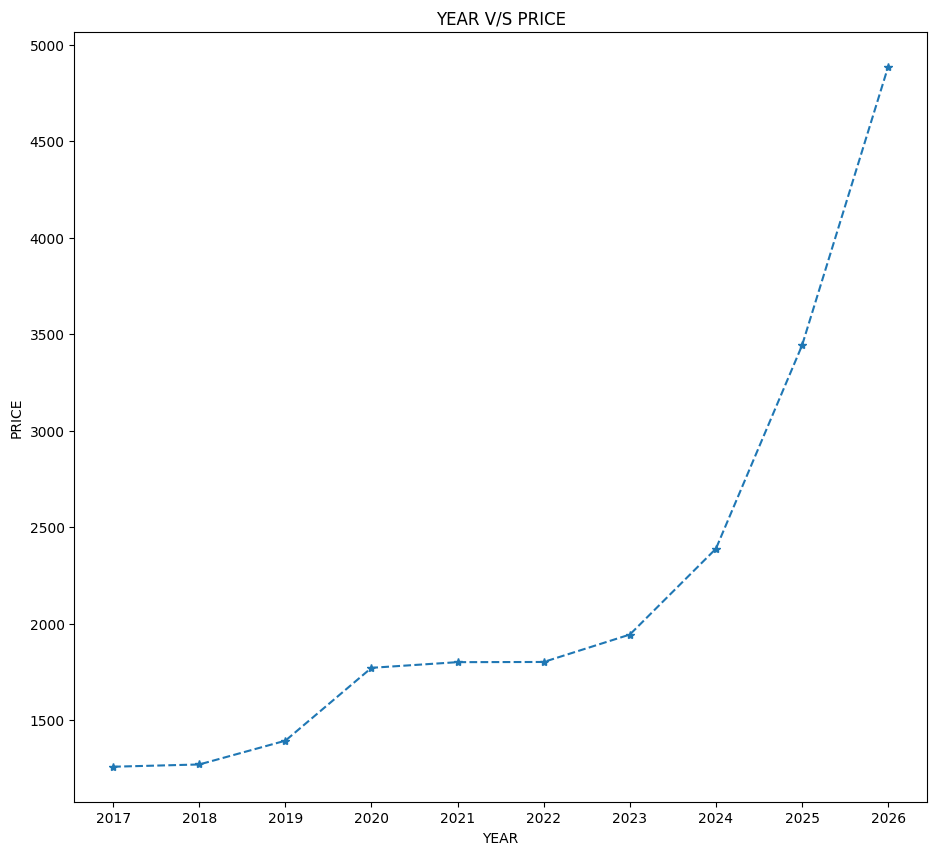

In [155]:
gr=df.groupby("Year")['Price'].mean().sort_index().tail(10)
gr.index=gr.index.astype(int)
plt.figure(figsize=(11,10))
plt.plot(gr.index,gr.values,ls="--",marker="*")
plt.xticks(gr.index)
plt.title("YEAR V/S PRICE")
plt.xlabel("YEAR")
plt.ylabel("PRICE")
plt.show()

In [156]:
yearly = df.groupby("Year")["Price"].mean().sort_index()
pct_change = yearly.pct_change() * 100
max_year = pct_change.idxmax()
max_value = pct_change.max()

print("Year with highest % change:", max_year)
print("Max % change:", int(max_value))

Year with highest % change: 1980
Max % change: 98


**THIS GRAPH HELP TO UNDESTAND MAX AND MIN PRICE IN A YEAR**

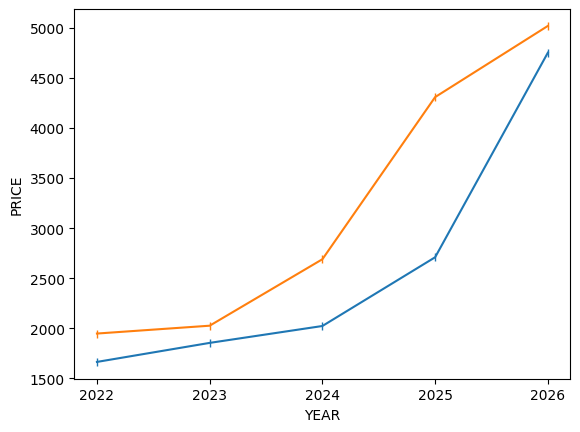

In [157]:
gf=df.groupby("Year")['Price'].agg(['max','min']).tail()
gf.index=gf.index.astype(int)
plt.plot(gf.index,gf['min'],label='MIN PRICE',marker="|")
plt.plot(gf.index,gf["max"],label="MAX PRICE",marker="|")
plt.xticks(gf.index)
plt.xlabel("YEAR")
plt.ylabel("PRICE")
plt.show()

In [158]:
gp=df.groupby('Month')["Price"].mean().sort_index()
pct_chnage=gp.pct_change()*100
max_month = pct_change.idxmax()
min_month=pct_change.idxmin()

print("Month with highest % change:", max_month)
print("Max % change:", pct_change.max())
print("Month with Lowest % change:", min_month)
print("Max % change:", pct_change.min())

Month with highest % change: 1980
Max % change: 98.21603745641994
Month with Lowest % change: 1981
Max % change: -24.365640898391494


In [ ]:
Negetive % Change Signify That Price Mostly Decrease in that month.

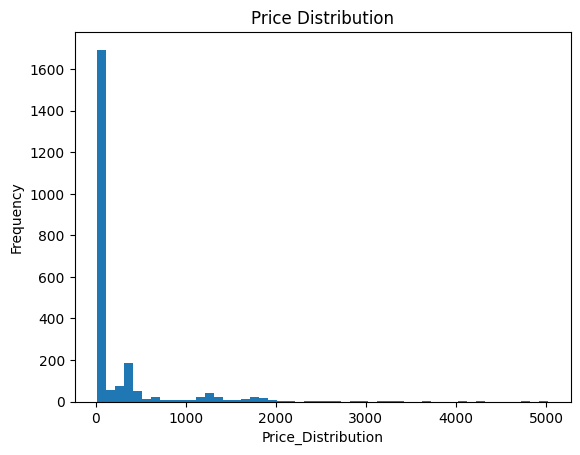

In [159]:
plt.hist(df["Price"],bins=50)
plt.title("Price Distribution")
plt.xlabel("Price_Distribution")
plt.ylabel("Frequency")
plt.show()